In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = {
    "Hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "Marks": [35, 40, 48, 52, 61, 65, 70, 78, 82, 90]
}

df = pd.DataFrame(data)

df

,Hours,Marks
0,1,35
1,2,40
2,3,48
3,4,52
4,5,61
5,6,65
6,7,70
7,8,78
8,9,82
9,10,90


In [3]:
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Hours   10 non-null     int64
 1   Marks   10 non-null     int64
dtypes: int64(2)
memory usage: 292.0 bytes
None

Summary Statistics:
          Hours      Marks
count  10.00000  10.000000
mean    5.50000  62.100000
std     3.02765  18.326969
min     1.00000  35.000000
25%     3.25000  49.000000
50%     5.50000  63.000000
75%     7.75000  76.000000
max    10.00000  90.000000


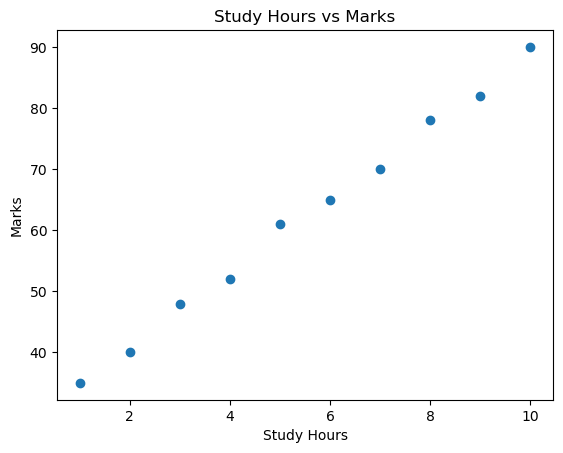

In [4]:
plt.scatter(df["Hours"], df["Marks"])

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Study Hours vs Marks")

plt.show()

In [5]:
X = df[["Hours"]]
y = df["Marks"]

# X = input feature
# y = target/output

print("X:")
print(X)

print("\ny:")
print(y)

X:
   Hours
0      1
1      2
2      3
3      4
4      5
5      6
6      7
7      8
8      9
9     10

y:
0    35
1    40
2    48
3    52
4    61
5    65
6    70
7    78
8    82
9    90
Name: Marks, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8
Testing samples: 2


In [7]:
model = LinearRegression()

In [8]:
model.fit(X_train, y_train)

LinearRegression()

In [9]:
slope = model.coef_[0]
intercept = model.intercept_

print("Slope:", slope)
print("Intercept:", intercept)

print(
    f"\nRegression Equation:"
    f" Marks = {slope:.2f} × Hours + {intercept:.2f}"
)

Slope: 6.060344827586208
Intercept: 29.043103448275858

Regression Equation: Marks = 6.06 × Hours + 29.04


In [10]:
print(
    f"For every 1-hour increase in study time, "
    f"the predicted marks increase by approximately {slope:.2f} marks."
)

For every 1-hour increase in study time, the predicted marks increase by approximately 6.06 marks.


In [11]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Hours": X_test["Hours"].values,
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred
})

results = results.sort_values("Hours")

results

,Hours,Actual Marks,Predicted Marks
1,2,40,41.163793
0,9,82,83.586207


In [12]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1.375
MSE : 1.935233353151013
RMSE: 1.3911266488537315
R²  : 0.9956117157524921


In [13]:
print("MAE  → Average absolute prediction error")
print("MSE  → Average squared prediction error")
print("RMSE → Typical prediction error in marks")
print("R²   → How much variation in marks is explained by the model")

MAE  → Average absolute prediction error
MSE  → Average squared prediction error
RMSE → Typical prediction error in marks
R²   → How much variation in marks is explained by the model


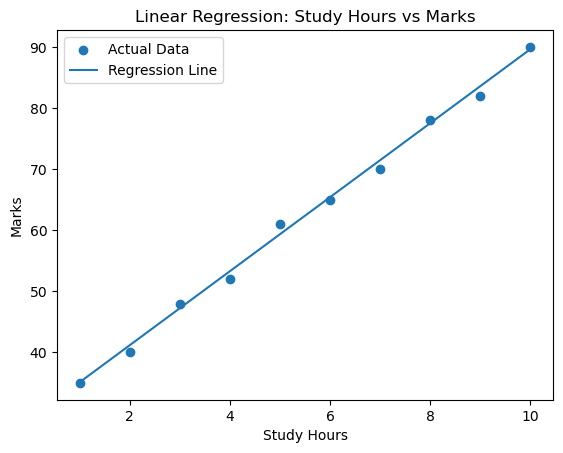

In [14]:
plt.scatter(
    df["Hours"],
    df["Marks"],
    label="Actual Data"
)

plt.plot(
    df["Hours"],
    model.predict(df[["Hours"]]),
    label="Regression Line"
)

plt.xlabel("Study Hours")
plt.ylabel("Marks")
plt.title("Linear Regression: Study Hours vs Marks")

plt.legend()
plt.show()

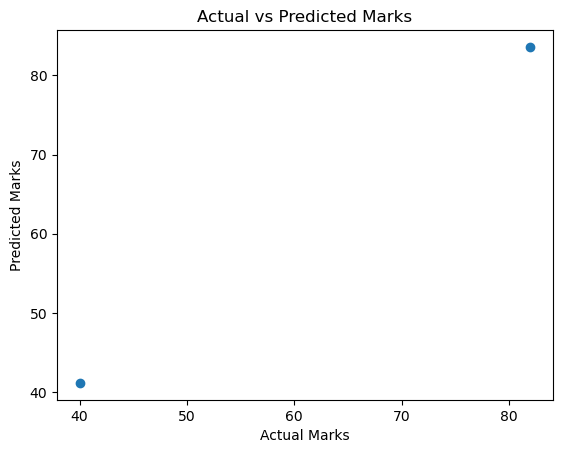

In [15]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")

plt.show()

In [16]:
residuals = y_test - y_pred

residual_df = pd.DataFrame({
    "Hours": X_test["Hours"].values,
    "Actual Marks": y_test.values,
    "Predicted Marks": y_pred,
    "Residual": residuals
})

residual_df = residual_df.sort_values("Hours")

residual_df

,Hours,Actual Marks,Predicted Marks,Residual
1,2,40,41.163793,-1.163793
8,9,82,83.586207,-1.586207


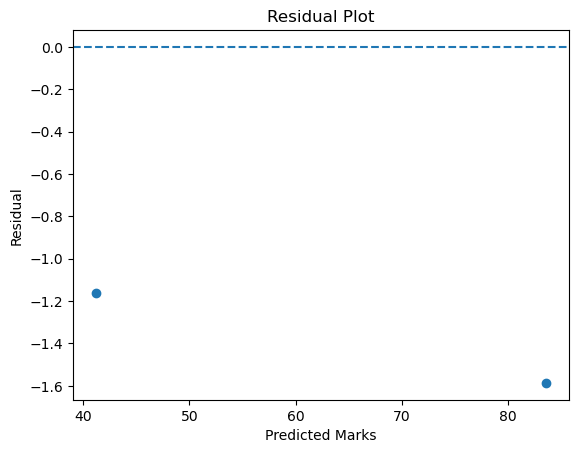

In [17]:
plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Marks")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [18]:
hours = [[7]]

prediction = model.predict(hours)

print("Predicted Marks:", prediction[0])

Predicted Marks: 71.46551724137932


E:\ anaconda yeeee\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [19]:
new_students = pd.DataFrame({
    "Hours": [3, 5, 7, 9, 11]
})

new_predictions = model.predict(new_students)

prediction_table = new_students.copy()

prediction_table["Predicted Marks"] = new_predictions

prediction_table

,Hours,Predicted Marks
0,3,47.224138
1,5,59.344828
2,7,71.465517
3,9,83.586207
4,11,95.706897


In [20]:
print("========== LINEAR REGRESSION SUMMARY ==========")

print(f"Coefficient : {model.coef_[0]:.4f}")
print(f"Intercept   : {model.intercept_:.4f}")

print(f"\nMAE         : {mae:.4f}")
print(f"MSE         : {mse:.4f}")
print(f"RMSE        : {rmse:.4f}")
print(f"R² Score    : {r2:.4f}")

print("\nRegression Equation:")
print(
    f"Marks = {model.coef_[0]:.2f} × Hours + "
    f"{model.intercept_:.2f}"
)

========== LINEAR REGRESSION SUMMARY ==========
Coefficient : 6.0603
Intercept   : 29.0431

MAE         : 1.3750
MSE         : 1.9352
RMSE        : 1.3911
R² Score    : 0.9956

Regression Equation:
Marks = 6.06 × Hours + 29.04
